# Least squares
In this File the algorithms are tested on the Least squares problem: 

$$min_{x \in \mathbb R^n} f(x)$$

Where $f(x) = \frac{1}{m} \lVert Ax -b \rVert^2$, $A \in \mathbb R^{m \times n}$, $b \in \mathbb R^m$.

Note that the gradient of f is given by $\nabla f(x) = \frac{2}{m} A^T (Ax - b)$, which is Lipschitz continous with Lipschitz constant $L = \frac{2}{m} \lVert A^T A \rVert = \frac{2}{m} \text{max}_{i = 1, \dots n} \lambda_i$ ($\lambda_i$ are the eigenvalues of $A^TA$)

The matrices $A$ that are used are bodyfat ($m=252$, $n=14$) and cadata ($m=20640$, $n=8$) from LIBSVM as well as two matrices with random entries in $[0,1)$: Random small ($m=1000$, $n=4000$), random large ($m=4000$, $n=8000$)

The data $b$ that is used is defined through a random (optimal) vector $x^*$ with entries in $[0,1)$ as $b = Ax^*$. Note that this implies that the optimal value of the minimization problem is 0.

In [1]:
import numpy as np
from AdaAGM import AdaAGM
from Algorithms import constant_gradient, Nesterov_gradient, AdaNAG_G
import matplotlib.pyplot as plt
import numpy.linalg as la

## Setting up 4 model problems

In [2]:
import os
from sklearn.datasets import load_svmlight_file
#loading bodyfat data
data_path = os.getcwd() + '\\datasets\\bodyfat'
data_matrix, data_vector = load_svmlight_file(data_path)

A_bodyfat = data_matrix.toarray()

#loading cadata data
data_path = os.getcwd() + '\\datasets\\cadata'
data_matrix, data_vector = load_svmlight_file(data_path)

A_cadata = data_matrix.toarray()

#creating random small data
A_random_small = np.random.rand(1000, 4000)

#creating random small data
A_random_large = np.random.rand(4000, 8000)

In [3]:
matrices = [A_bodyfat, A_cadata, A_random_small, A_random_large]

iteration_list = [20000, 100000, 6000, 10000]

## Setting up AdaAGM
Corollary 4.3 gives the following constants:
$\gamma = \frac{1}{2}, \beta = 1$, $m = 0.5 \in (0,1)$, $t_0 = 2$ and $\omega = \delta = 0$

Also the initial stepsize needs to satisfy the follwing: $s_0 \geq \frac{4}{L}$, which is guaranteed during the calculation of sequences.

In [4]:
t_0 = 2
m = 0.5
omega = 1/2
delta = 1/2
beta = 1
gamma = 1/2

## Setting up AdaNAG_G$_{12}$ 
### Choices of constants and sequences
Corollary 7 gives the follwing: $\tau_k = \frac{(k+2) + 12}{12}$, $\alpha_k = \frac{1}{2} \frac{(\tau_{k+1} - 1)^2}{\tau_k^2}$ and $B_0 = \alpha_0^2\tau_0^2(\frac{(\tau_0 - 1)^2}{\alpha_{-1}\tau_{-1}^2} -1)$

In [5]:
tau_12 = lambda k: ((k+2) + 12)/12
alpha = lambda tau_k, tau_k1: 1/2 * (tau_k1 - 1)**2/tau_k**2
tau_m1 = tau_12(-1)
tau_0 = tau_12(0)
tau_1 = tau_12(1)
alpha_m1 = alpha(tau_m1, tau_0)
alpha_0 = alpha(tau_0, tau_1)
B_0 = alpha_0**2 * tau_0**2 *((tau_0-1)**2/(alpha_m1*tau_m1**2) - 1)

### Initial stepsize
The paper defines the initial stepsize in the follwoing way: $s_0 = \frac{A_0}{\alpha_0\tau_0} \frac{r}{\alpha_1} \frac{1}{L_0}$

Here $A_0$, $\alpha_0$, $\tau_0$ and $\alpha_1$ are given by the Algorithm.

$L_0$ is defined as: $L_0 = \frac{\lVert \nabla f(x_0) - \nabla f(\tilde{x}_0) \rVert}{\lVert x_0 - \tilde{x}_0 \rVert}$ with $x_0$ the starting value and $\tilde{x}_0 = x_0 + u$, where the entries of u are random in $[0,1)$.

And the Proof of Corollary 7 yields a choice of $r = \alpha_1 r_0^L$ with $r_k^L = (\frac{A_k}{B_k} + \frac{B_{k+1} + \alpha_{k+1}^2 \tau_{k+1}^2}{A_k})^{-1}$

In [6]:
def initial_stepize_AdaNAG_G_12(tau, alpha, B_0, L_0):
    """
    Calculate the initial stepsize of AdaNAG_G_12 given in the paper
    
    Note for AdaNAG_G_1/2: only the choice of r is different: r = 1/10
    """
    tau_m1 = tau(-1)
    tau_0 = tau(0)
    tau_1 = tau(1)
    
    alpha_0 = alpha(tau_m1, tau_0)
    alpha_1 = alpha(tau_0, tau_1)
    A_0 = alpha_1*tau_1*(tau_1 - 1)
    B_1 = alpha_1**2 * tau_1**2 * ((tau_1)**2/(alpha_0 * tau_0**2) - 1)

    r_0_L = 1/(A_0/B_0 + (B_1 + alpha_1**2 * tau_1**2)/A_0)
    r = alpha_1*r_0_L

    return A_0/(alpha_0*tau_0) * r/alpha_1 * 1/L_0

## Calculation of sequences

In [7]:
iterates = []
values = []
gradient_norms = []

for n in range(4):
    iterations = iteration_list[n]
    A = matrices[n]
    num_rows, num_cols = np.shape(A)
    #this means that the optimal function value is 0
    x_optimal = np.random.rand(num_cols)
    b = A @ x_optimal
    
    function = lambda x: 1/num_rows*np.linalg.norm(A @ x - b)**2
    gradient = lambda x: 2/num_rows*A.T @ (A @ x - b)
    
    x_0 = np.zeros(num_cols)
    y_0 = x_0
    
    #Lipschitz constant of problem:
    L = 2/num_rows * np.max(la.eigvalsh(A.T @ A))
    
    #choice of initial stepsices
    #Nesterov and constant gradient require s_0 < 1/L
    s_0_const = 1/L
    #definition in Paper
    x_0_tilde = np.random.rand(num_cols)
    L_0 = la.norm(gradient(x_0) - gradient(x_0_tilde))/la.norm(x_0 - x_0_tilde)
    s_0_AdaNAG_G = initial_stepize_AdaNAG_G_12(tau_12, alpha, B_0, L_0)
    
    #Definition in Paper s_0 >= 1/(4L)
    s_0_AdaAGM = 1/(4*L)
    
    sol_const_gradient = constant_gradient(function, gradient, x_0, s_0_const, iterations)
    print('const_gradient Done')
    sol_Nesterov = Nesterov_gradient(function, gradient, x_0, s_0_const, iterations)
    print('Nesterov Done')
    sol_Ada_NAG_G = AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G, iterations, tau_12, alpha, B_0)
    print('AdaNAG_G Done')
    sol_AdaAGM = AdaAGM(function, gradient, x_0, y_0, gamma, t_0, m, s_0_AdaAGM, omega, delta, beta, iterations)
    print('AdaAGM Done')
    
    iterates.append([])
    iterates[n].append(sol_const_gradient[0])
    iterates[n].append(sol_Nesterov[0])
    iterates[n].append(sol_Ada_NAG_G[0])
    iterates[n].append(sol_AdaAGM[0])
    
    values.append([])
    values[n].append(sol_const_gradient[1])
    values[n].append(sol_Nesterov[1])
    values[n].append(sol_Ada_NAG_G[1])
    values[n].append(sol_AdaAGM[1])
    
    gradient_norms.append([])
    gradient_norms[n].append(sol_const_gradient[2])
    gradient_norms[n].append(sol_Nesterov[2])
    gradient_norms[n].append(sol_Ada_NAG_G[2])
    gradient_norms[n].append(sol_AdaAGM[2])

const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done
const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done
const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done
const_gradient Done
Nesterov Done
AdaNAG_G Done
AdaAGM Done


## Plots of function values

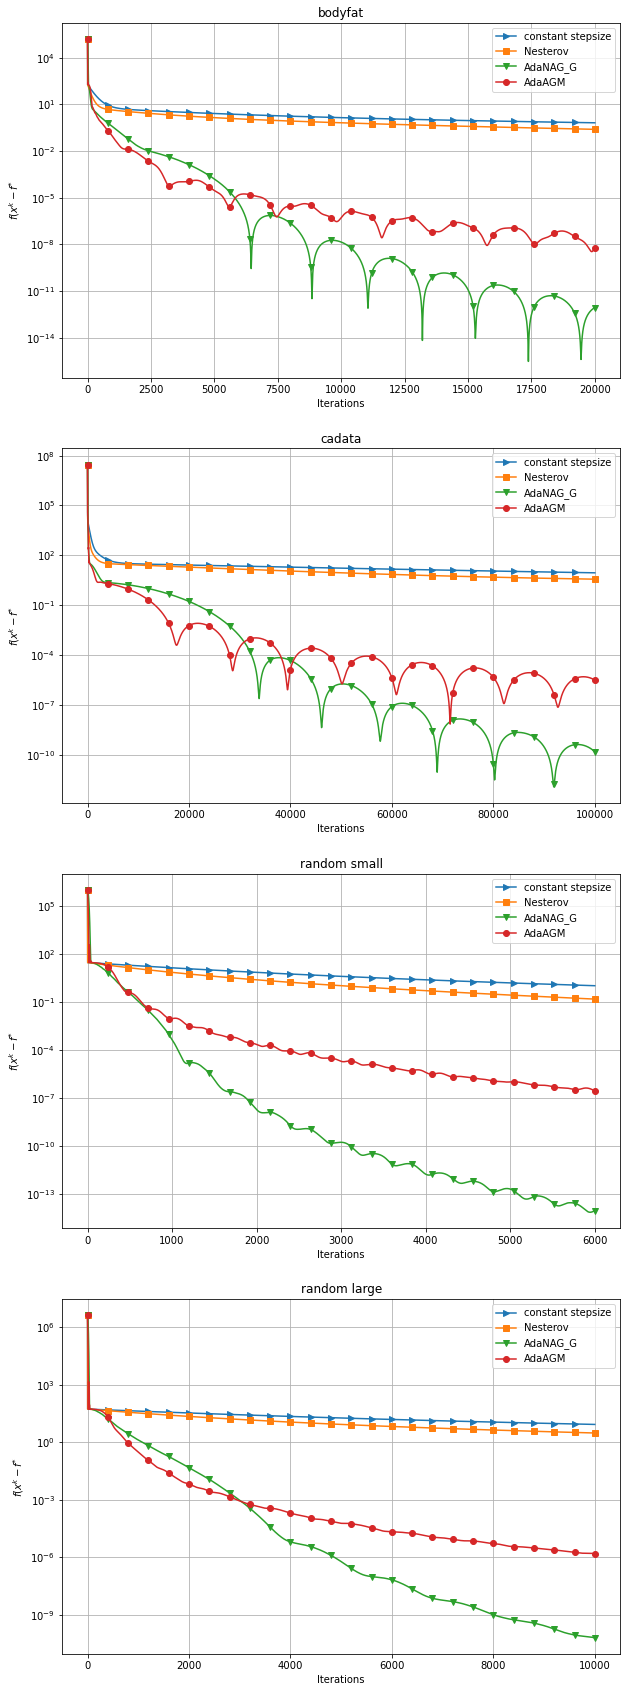

In [20]:
fig, ax = plt.subplots(4, figsize=(10,30))
labels = ['constant stepsize', 'Nesterov', 'AdaNAG_G', 'AdaAGM']
titles = ['bodyfat', 'cadata', 'random small', 'random large']
markers = ['>', 's', 'v', 'o']
mark_every = [800, 4000, 240, 400]
for k in range(4):
    for index, value_sequence in enumerate(values[k]):
        ax[k].plot(value_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$f(x^{k} - f^{*}$')
    ax[k].grid()

## Plots of gradient norms

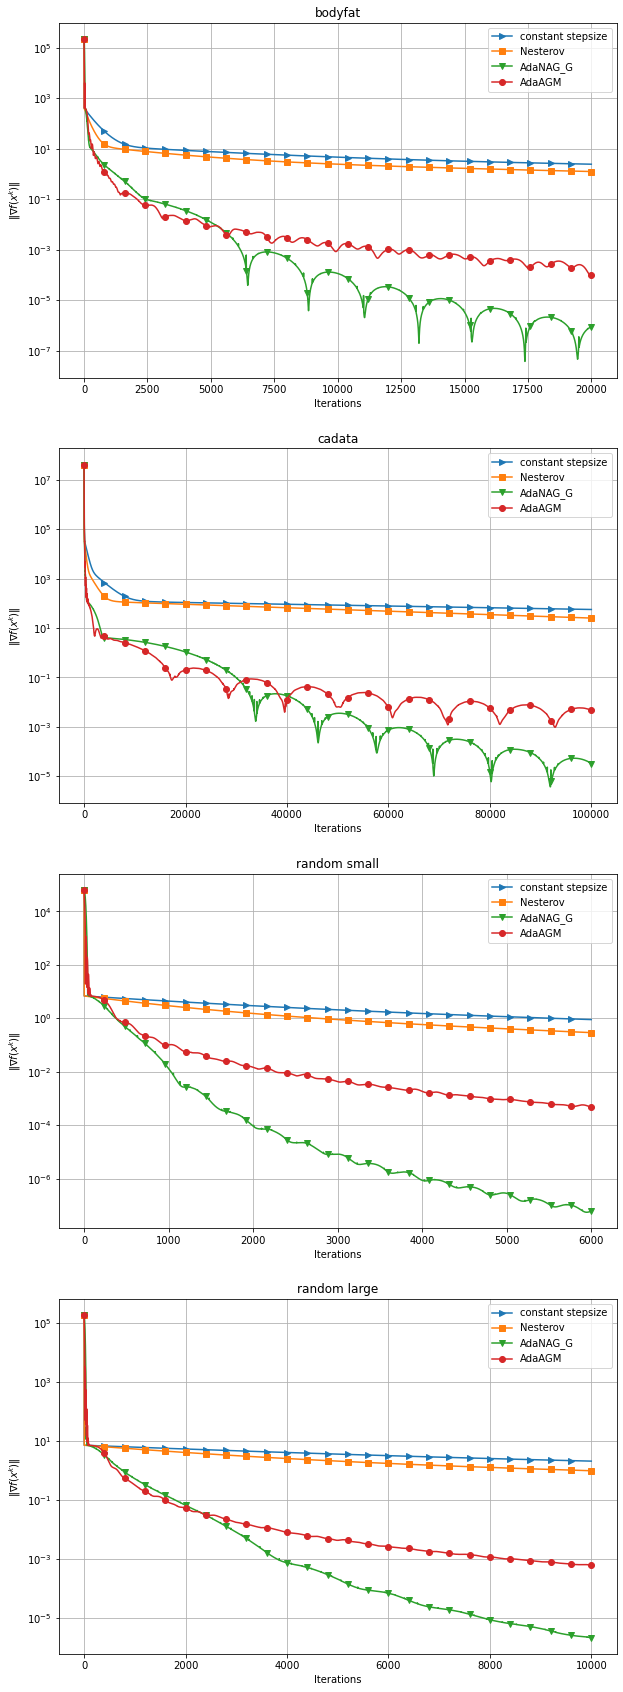

In [19]:
fig, ax = plt.subplots(4, figsize=(10,30))
for k in range(4):
    for index, gradient_sequence in enumerate(gradient_norms[k]):
        ax[k].plot(gradient_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$\Vert \nabla f(x^k) \Vert$')
    ax[k].grid()